# 03. Train/Test 분할, EDA와 통계분석

## tl;dr

- 훈련 데이터는 **26,048행**, 테스트 데이터는 **6,513행**이며 혼인 경험 비율은 각각 약 67.19%입니다.
- 나이는 혼인 경험과 가장 강한 숫자형 관련성을 보였습니다(`r=0.534`, `Cohen's d=1.345`).
- Mutual Information도 나이가 `0.212`로 가장 높았습니다.
- `income`은 가장 큰 범주형 관련성(`Cramér's V=0.317`)을 보였지만 현재 시점 정보이므로 확장 모델에서만 사용합니다.

## Context & Methods

모델 선택에 테스트 정보가 섞이지 않도록 타깃 비율을 유지한 train/test 분할을 먼저 수행합니다. 모든 EDA, 통계검정, Mutual Information은 훈련 데이터에서만 계산합니다.

### Key Assumptions

- Welch t-test는 두 집단 평균 차이를 검정합니다.
- 큰 표본에서는 작은 차이도 유의할 수 있어 Cohen's d를 함께 봅니다.
- 상관관계와 MI는 예측 관련성이지 인과효과가 아닙니다.
- 범주형 변수에는 Pearson 상관계수를 적용하지 않습니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-analysis 프로젝트 루트에서 실행하세요.')
sys.path.insert(0, str(project_root))

from src.data import add_target_pandas, ensure_raw_data, load_with_pandas
from src.eda import (
    build_categorical_summary,
    build_categorical_target_rates,
    build_iqr_outlier_summary,
    build_numeric_correlation,
    build_numeric_distribution_summary,
    build_numeric_target_summary,
)
from src.statistics import (
    analyze_categorical_associations,
    analyze_numeric_associations,
    build_descriptive_statistics,
    build_split_summary,
    calculate_mutual_information,
    split_prepared_data,
)
from src.visualization import (
    build_age_rate_figure,
    create_categorical_cardinality_chart,
    create_categorical_target_rate_chart,
    create_correlation_heatmap,
    create_age_distribution_chart,
    create_interactive_age_rate_chart,
    create_numeric_distribution_grid,
    create_numeric_target_boxplots,
    create_outlier_boxplots,
    create_split_target_distribution_chart,
    create_target_association_overview,
)

## Data

### 1. 타깃 생성 후 stratified 분할

In [2]:
raw_path = ensure_raw_data(project_root / 'data' / 'raw')
prepared_df = add_target_pandas(load_with_pandas(raw_path))
train_df, test_df = split_prepared_data(prepared_df)
split_summary = build_split_summary(train_df, test_df)
split_summary

,split,ever_married,count,percentage
0,train,0,8546,32.808661
1,train,1,17502,67.191339
2,test,0,2137,32.811300
3,test,1,4376,67.188700


### 1-1. Stratified 분할에서 Target 비율이 유지됐는가?

80:20은 행을 나누는 비율이고, 32.81:67.19는 각 분할 안의 Target 클래스 비율입니다.

[Question] Train과 Test에 Target 비율이 동일하게 유지됐는가?
[Observed] Train과 Test 모두 Target 0 약 32.81%, Target 1 약 67.19%입니다.
[Next Action] 두 분할의 클래스 구성이 같으므로 최종 성능을 비교합니다.


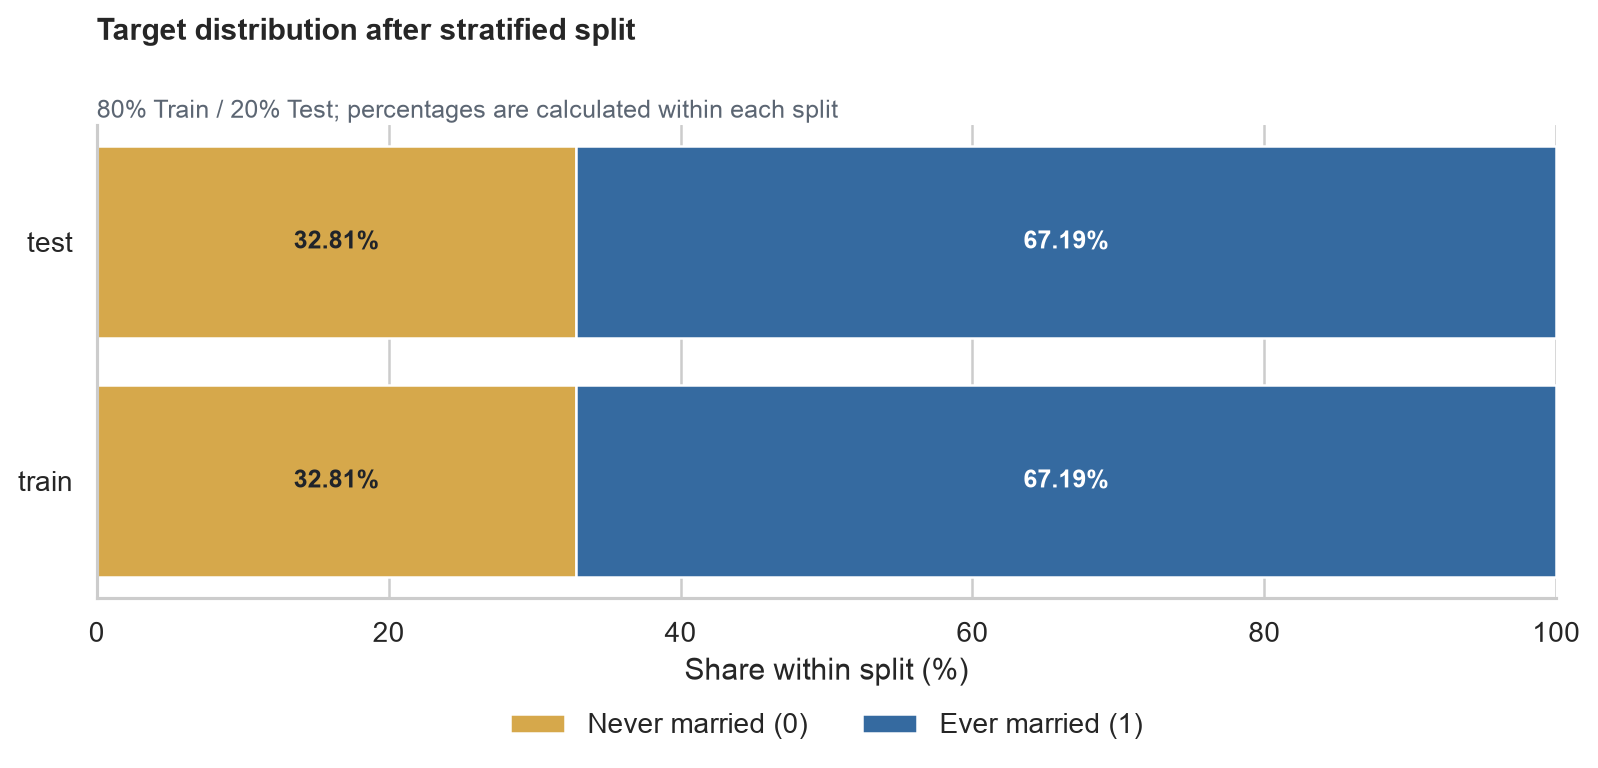

In [3]:
split_target_chart_path = create_split_target_distribution_chart(
    split_summary,
    project_root / 'reports' / 'figures' / 'eda_stratified_target_split.png',
)
print('[Question] Train과 Test에 Target 비율이 동일하게 유지됐는가?')
print('[Observed] Train과 Test 모두 Target 0 약 32.81%, Target 1 약 67.19%입니다.')
print('[Next Action] 두 분할의 클래스 구성이 같으므로 최종 성능을 비교합니다.')
display(Image(filename=str(split_target_chart_path)))

## Results

### 2. 수치형 변수들의 분포는 어떠한가?

평균·중앙값·왜도·0의 비율을 표로 확인하고, 원본 스케일 히스토그램을 함께 봅니다.

In [4]:
numeric_distribution = build_numeric_distribution_summary(train_df)
print('[Question] 수치형 변수들의 분포는 어떠한가?')
display(numeric_distribution.round(3))
skewed_features = numeric_distribution.loc[numeric_distribution.skewness.abs() > 2, 'feature'].tolist()
print(f'[Observed] |skewness| > 2인 변수: {skewed_features}')
print('[Next Action] capital-gain·capital-loss는 모델 Pipeline 안에서 log1p 변환합니다.')

[Question] 수치형 변수들의 분포는 어떠한가?


,feature,count,mean,median,std,min,max,skewness,zero_rate_pct
0,age,26048,38.591,37.0,13.619,17.0,90.0,0.553,0.000
1,education-num,26048,10.088,10.0,2.568,1.0,16.0,-0.319,0.000
2,hours-per-week,26048,40.433,40.0,12.348,1.0,99.0,0.209,0.000
3,capital-gain,26048,1103.996,0.0,7552.141,0.0,99999.0,11.751,91.615
4,capital-loss,26048,87.577,0.0,403.653,0.0,4356.0,4.574,95.332


[Observed] |skewness| > 2인 변수: ['capital-gain', 'capital-loss']
[Next Action] capital-gain·capital-loss는 모델 Pipeline 안에서 log1p 변환합니다.


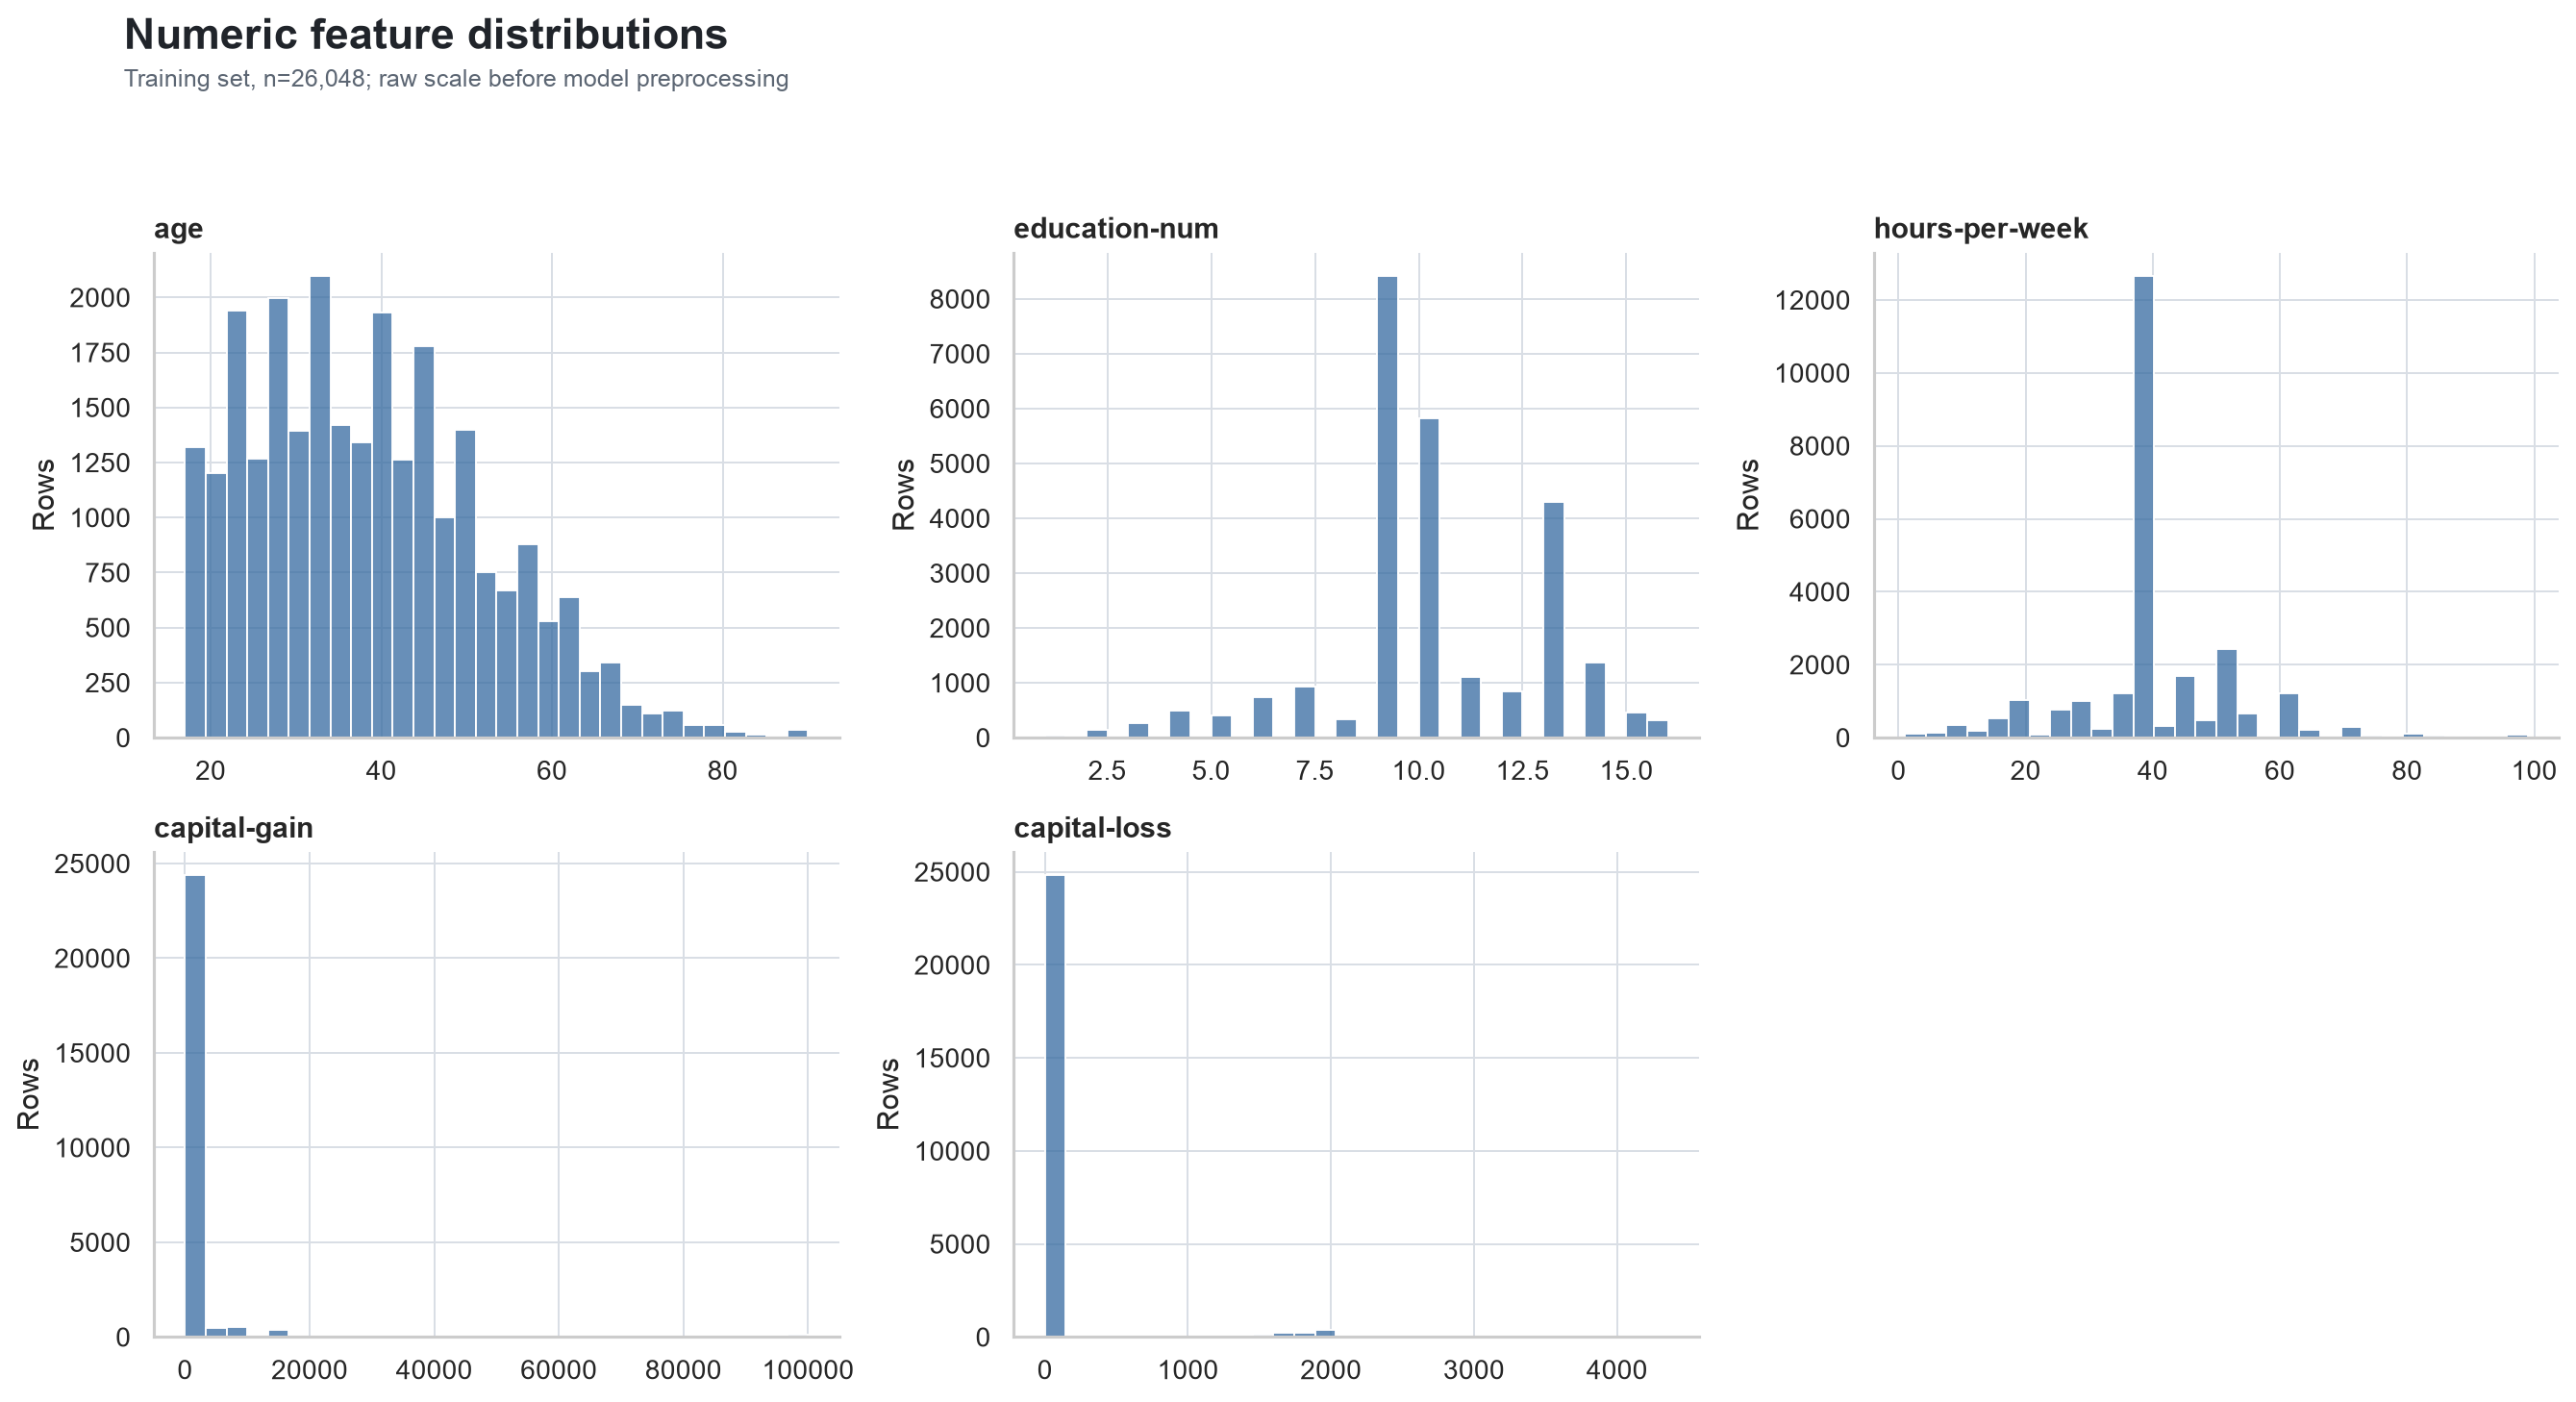

In [5]:
distribution_chart_path = create_numeric_distribution_grid(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_numeric_distributions.png',
)
display(Image(filename=str(distribution_chart_path)))

### 3. 이상치는 존재하는가?

1.5×IQR 기준은 잠재적 극단값을 찾기 위한 진단 도구이며, 발견된 행을 자동 삭제하지 않습니다.

In [6]:
outlier_summary = build_iqr_outlier_summary(train_df)
print('[Question] 이상치는 존재하는가?')
display(outlier_summary.round(3))
print('[Next Action] Adult의 실제 관측 가능 값이므로 삭제하지 않고, 긴 꼬리는 log1p와 StandardScaler로 처리합니다.')

[Question] 이상치는 존재하는가?


,feature,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_rate_pct
0,hours-per-week,40.0,45.0,5.0,32.5,52.5,7224,27.733
1,capital-gain,0.0,0.0,0.0,0.0,0.0,2184,8.385
2,capital-loss,0.0,0.0,0.0,0.0,0.0,1216,4.668
3,education-num,9.0,12.0,3.0,4.5,16.5,948,3.639
4,age,28.0,48.0,20.0,-2.0,78.0,113,0.434


[Next Action] Adult의 실제 관측 가능 값이므로 삭제하지 않고, 긴 꼬리는 log1p와 StandardScaler로 처리합니다.


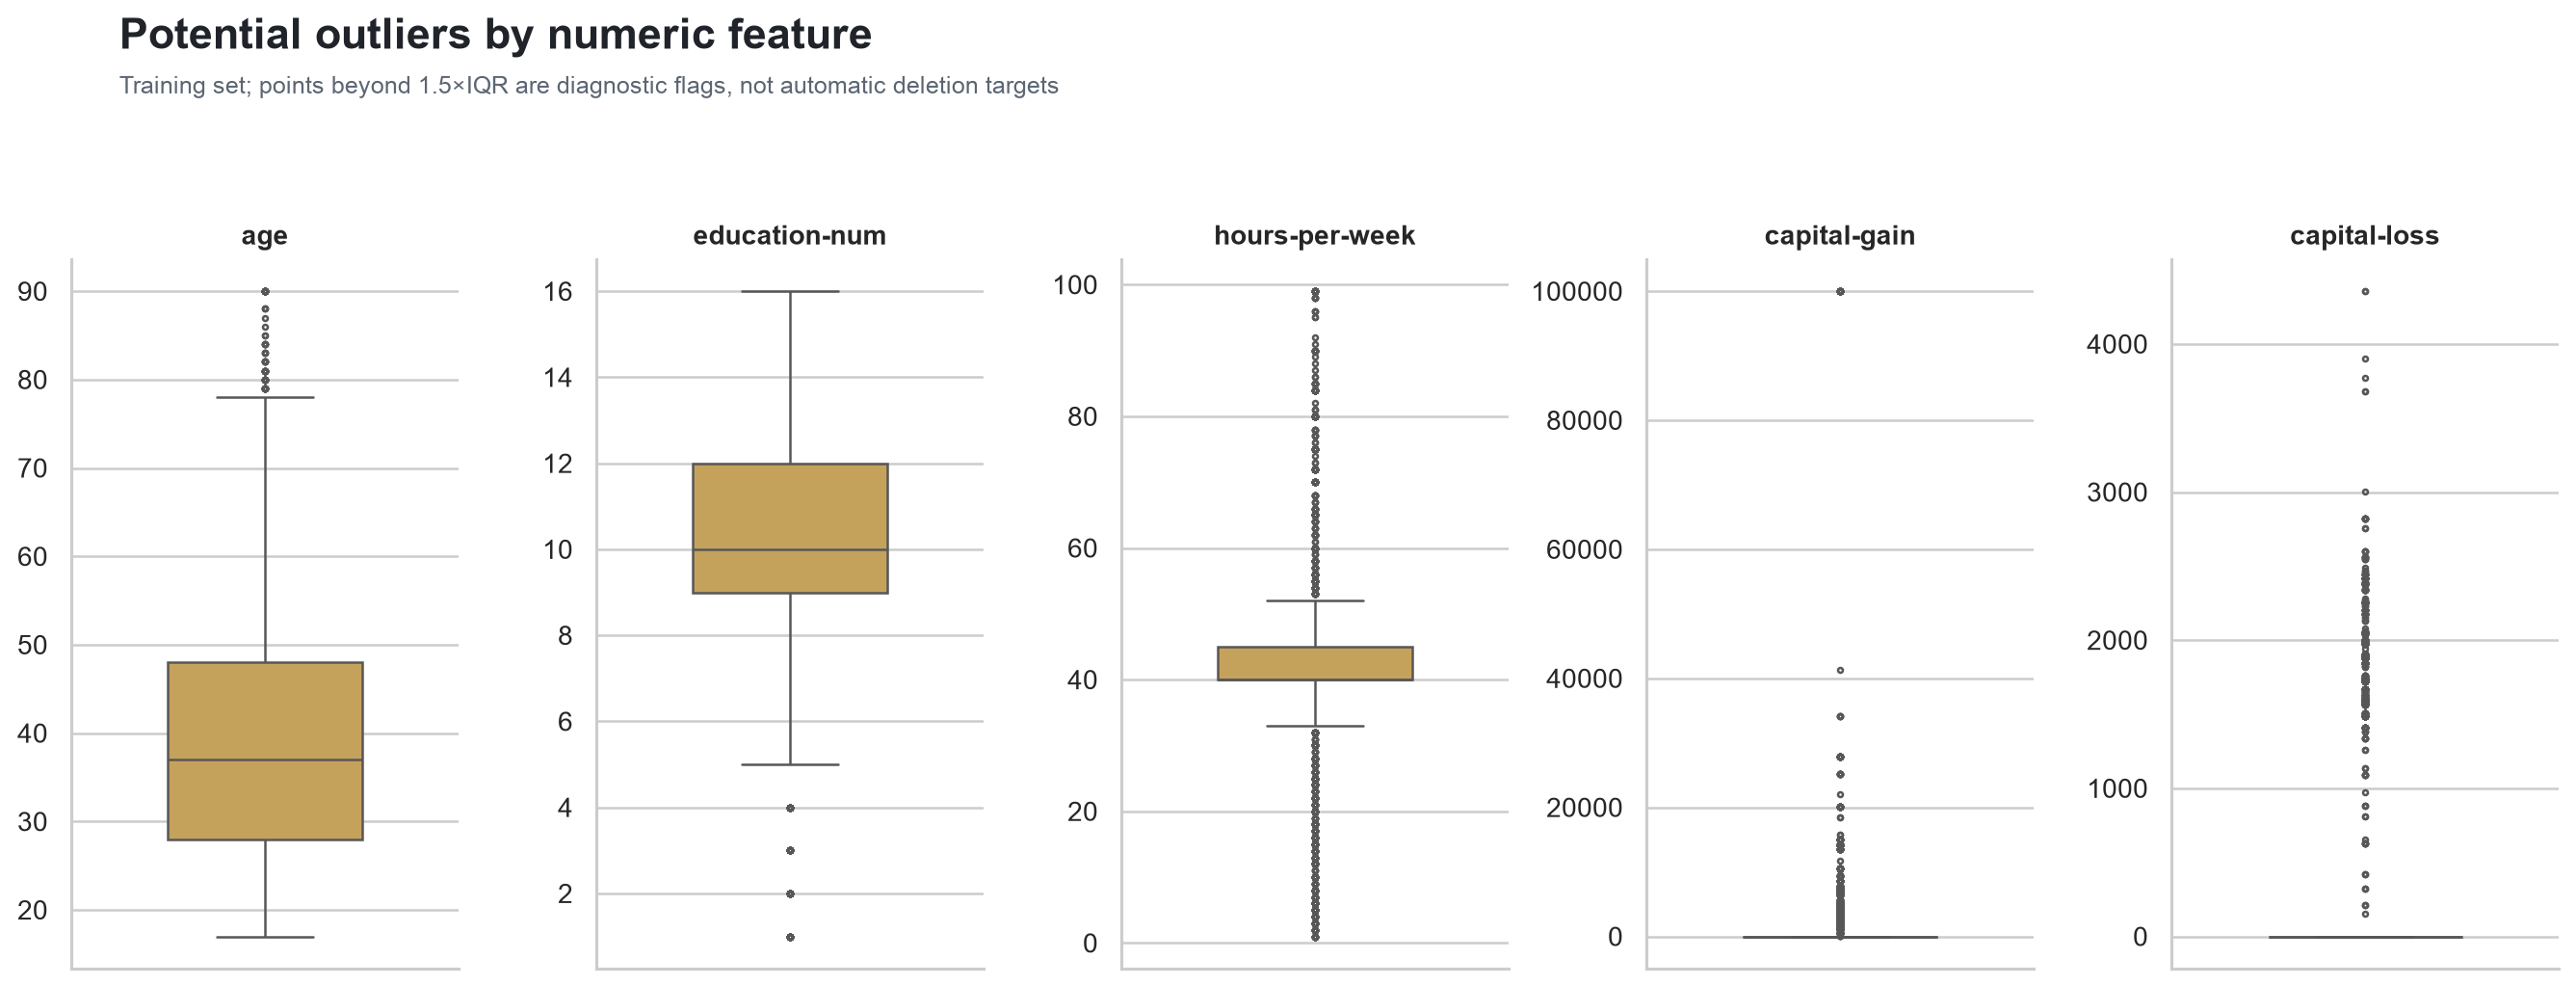

In [7]:
outlier_chart_path = create_outlier_boxplots(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_numeric_outliers.png',
)
display(Image(filename=str(outlier_chart_path)))

### 4. 범주형 변수의 구성과 빈도는 적절한가?

고유 범주 수, 결측치, 최빈 범주의 비율을 확인해 대치·인코딩 방법을 결정합니다.

In [8]:
categorical_summary = build_categorical_summary(train_df)
print('[Question] 범주형 변수의 구성과 빈도는 적절한가?')
display(categorical_summary.round(3))
print('[Next Action] 결측은 Unknown으로 대치하고 OneHotEncoder(handle_unknown=ignore)를 사용합니다.')

[Question] 범주형 변수의 구성과 빈도는 적절한가?


,feature,cardinality_including_missing,missing_count,top_category,top_count,top_share_pct
0,workclass,9,1506,Private,18168,69.748
1,occupation,15,1512,Prof-specialty,3345,12.842
2,income,2,0,<=50K,19797,76.002


[Next Action] 결측은 Unknown으로 대치하고 OneHotEncoder(handle_unknown=ignore)를 사용합니다.


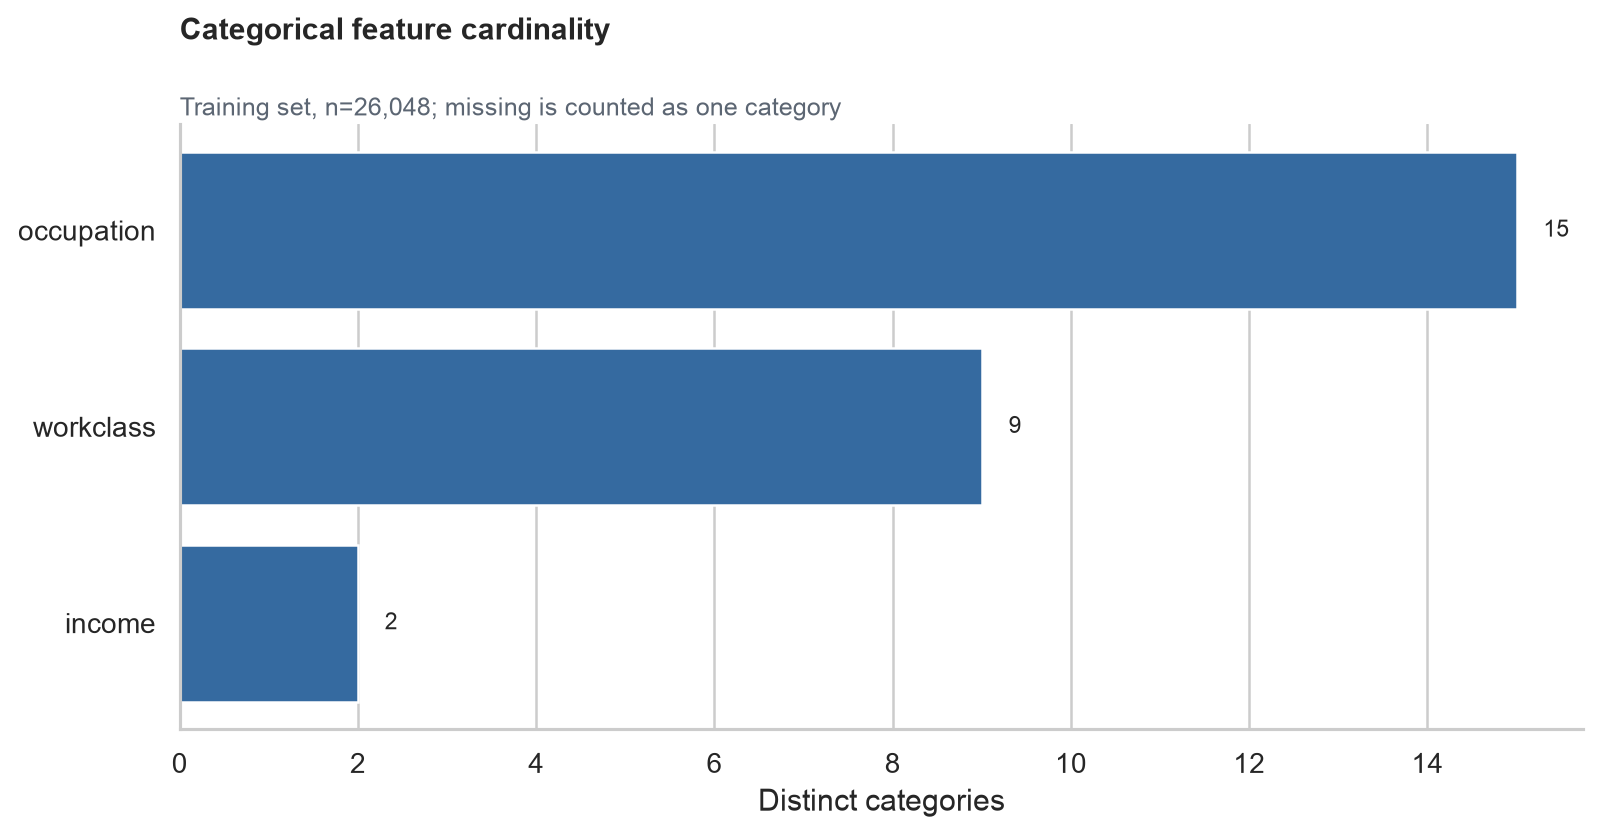

In [9]:
categorical_chart_path = create_categorical_cardinality_chart(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_categorical_cardinality.png',
)
display(Image(filename=str(categorical_chart_path)))

### 5. 서로 비슷한 정보를 가진 숫자형 변수는 없는가?

숫자형 후보 간 Pearson 상관행렬을 표와 heatmap으로 확인합니다.

In [10]:
numeric_correlation = build_numeric_correlation(train_df)
print('[Question] 서로 비슷한 정보를 가진 숫자형 변수는 없는가?')
display(numeric_correlation.round(3))
print('[Next Action] heatmap에서 강한 중복 상관이 있는지 확인하고, 최종 선택은 교차검증으로 판단합니다.')

[Question] 서로 비슷한 정보를 가진 숫자형 변수는 없는가?


,age,education-num,hours-per-week,capital-gain,capital-loss
age,1.000,0.035,0.068,0.076,0.057
education-num,0.035,1.000,0.146,0.120,0.079
hours-per-week,0.068,0.146,1.000,0.077,0.054
capital-gain,0.076,0.120,0.077,1.000,-0.032
capital-loss,0.057,0.079,0.054,-0.032,1.000


[Next Action] heatmap에서 강한 중복 상관이 있는지 확인하고, 최종 선택은 교차검증으로 판단합니다.


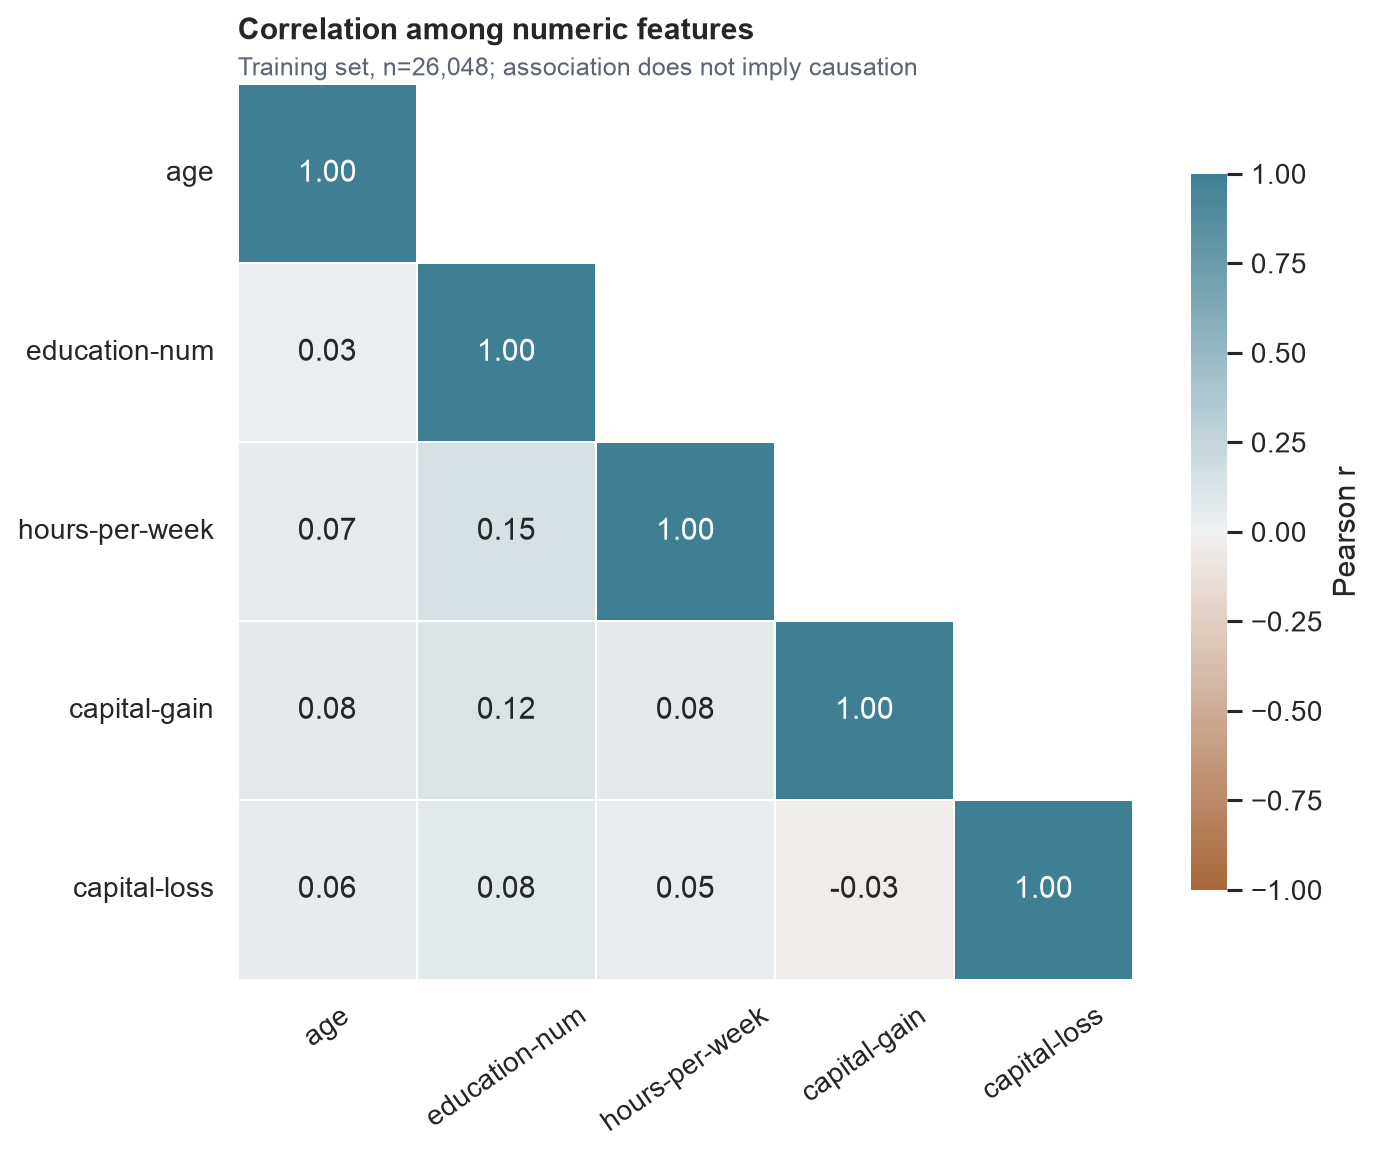

In [11]:
correlation_chart_path = create_correlation_heatmap(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_numeric_correlation.png',
)
display(Image(filename=str(correlation_chart_path)))

### 6. 숫자형 기술통계 — 혼인 경험 집단별

In [12]:
descriptive_statistics = build_descriptive_statistics(train_df)
descriptive_statistics.round(3)

,ever_married,feature,count,mean,std,var,median,min,max
0,0,age,8546,28.184,10.031,1.006240e+02,25.0,17,90
1,0,education-num,8546,9.978,2.384,5.681000e+00,10.0,1,16
2,0,hours-per-week,8546,36.919,12.400,1.537630e+02,40.0,1,99
3,0,capital-gain,8546,396.438,4033.960,1.627283e+07,0.0,0,99999
4,0,capital-loss,8546,51.971,305.705,9.345581e+04,0.0,0,3683
5,1,age,17502,43.673,12.174,1.481980e+02,42.0,17,90
6,1,education-num,17502,10.141,2.652,7.036000e+00,10.0,1,16
7,1,hours-per-week,17502,42.149,11.953,1.428750e+02,40.0,1,99
8,1,capital-gain,17502,1449.487,8750.806,7.657661e+07,0.0,0,99999
9,1,capital-loss,17502,104.963,442.660,1.959479e+05,0.0,0,4356


### 7. Target 그룹에 따라 수치형 변수의 분포가 다른가?

Target=0(혼인 경험 없음)과 Target=1(혼인 경험 있음)의 중앙값·분포를 전체 숫자형 후보에 대해 비교합니다.

In [13]:
numeric_target_summary = build_numeric_target_summary(train_df)
print('[Question] Target 그룹에 따라 수치형 변수의 분포가 다른가?')
display(numeric_target_summary.round(3))
print('[Observed] 나이의 집단 차이가 가장 크며, 통계검정과 효과크기로 다음 셀에서 확인합니다.')
print('[Next Action] 그림만으로 변수를 확정하지 않고 Point-biserial·Welch t-test·Cohen d를 함께 봅니다.')

[Question] Target 그룹에 따라 수치형 변수의 분포가 다른가?


,feature,ever_married,sample_size,mean,median,std,q1,q3
0,age,0,8546,28.184,25.0,10.031,21.0,32.0
1,age,1,17502,43.673,42.0,12.174,34.0,52.0
2,education-num,0,8546,9.978,10.0,2.384,9.0,12.0
3,education-num,1,17502,10.141,10.0,2.652,9.0,13.0
4,hours-per-week,0,8546,36.919,40.0,12.400,30.0,40.0
5,hours-per-week,1,17502,42.149,40.0,11.953,40.0,48.0
6,capital-gain,0,8546,396.438,0.0,4033.960,0.0,0.0
7,capital-gain,1,17502,1449.487,0.0,8750.806,0.0,0.0
8,capital-loss,0,8546,51.971,0.0,305.705,0.0,0.0
9,capital-loss,1,17502,104.963,0.0,442.660,0.0,0.0


[Observed] 나이의 집단 차이가 가장 크며, 통계검정과 효과크기로 다음 셀에서 확인합니다.
[Next Action] 그림만으로 변수를 확정하지 않고 Point-biserial·Welch t-test·Cohen d를 함께 봅니다.


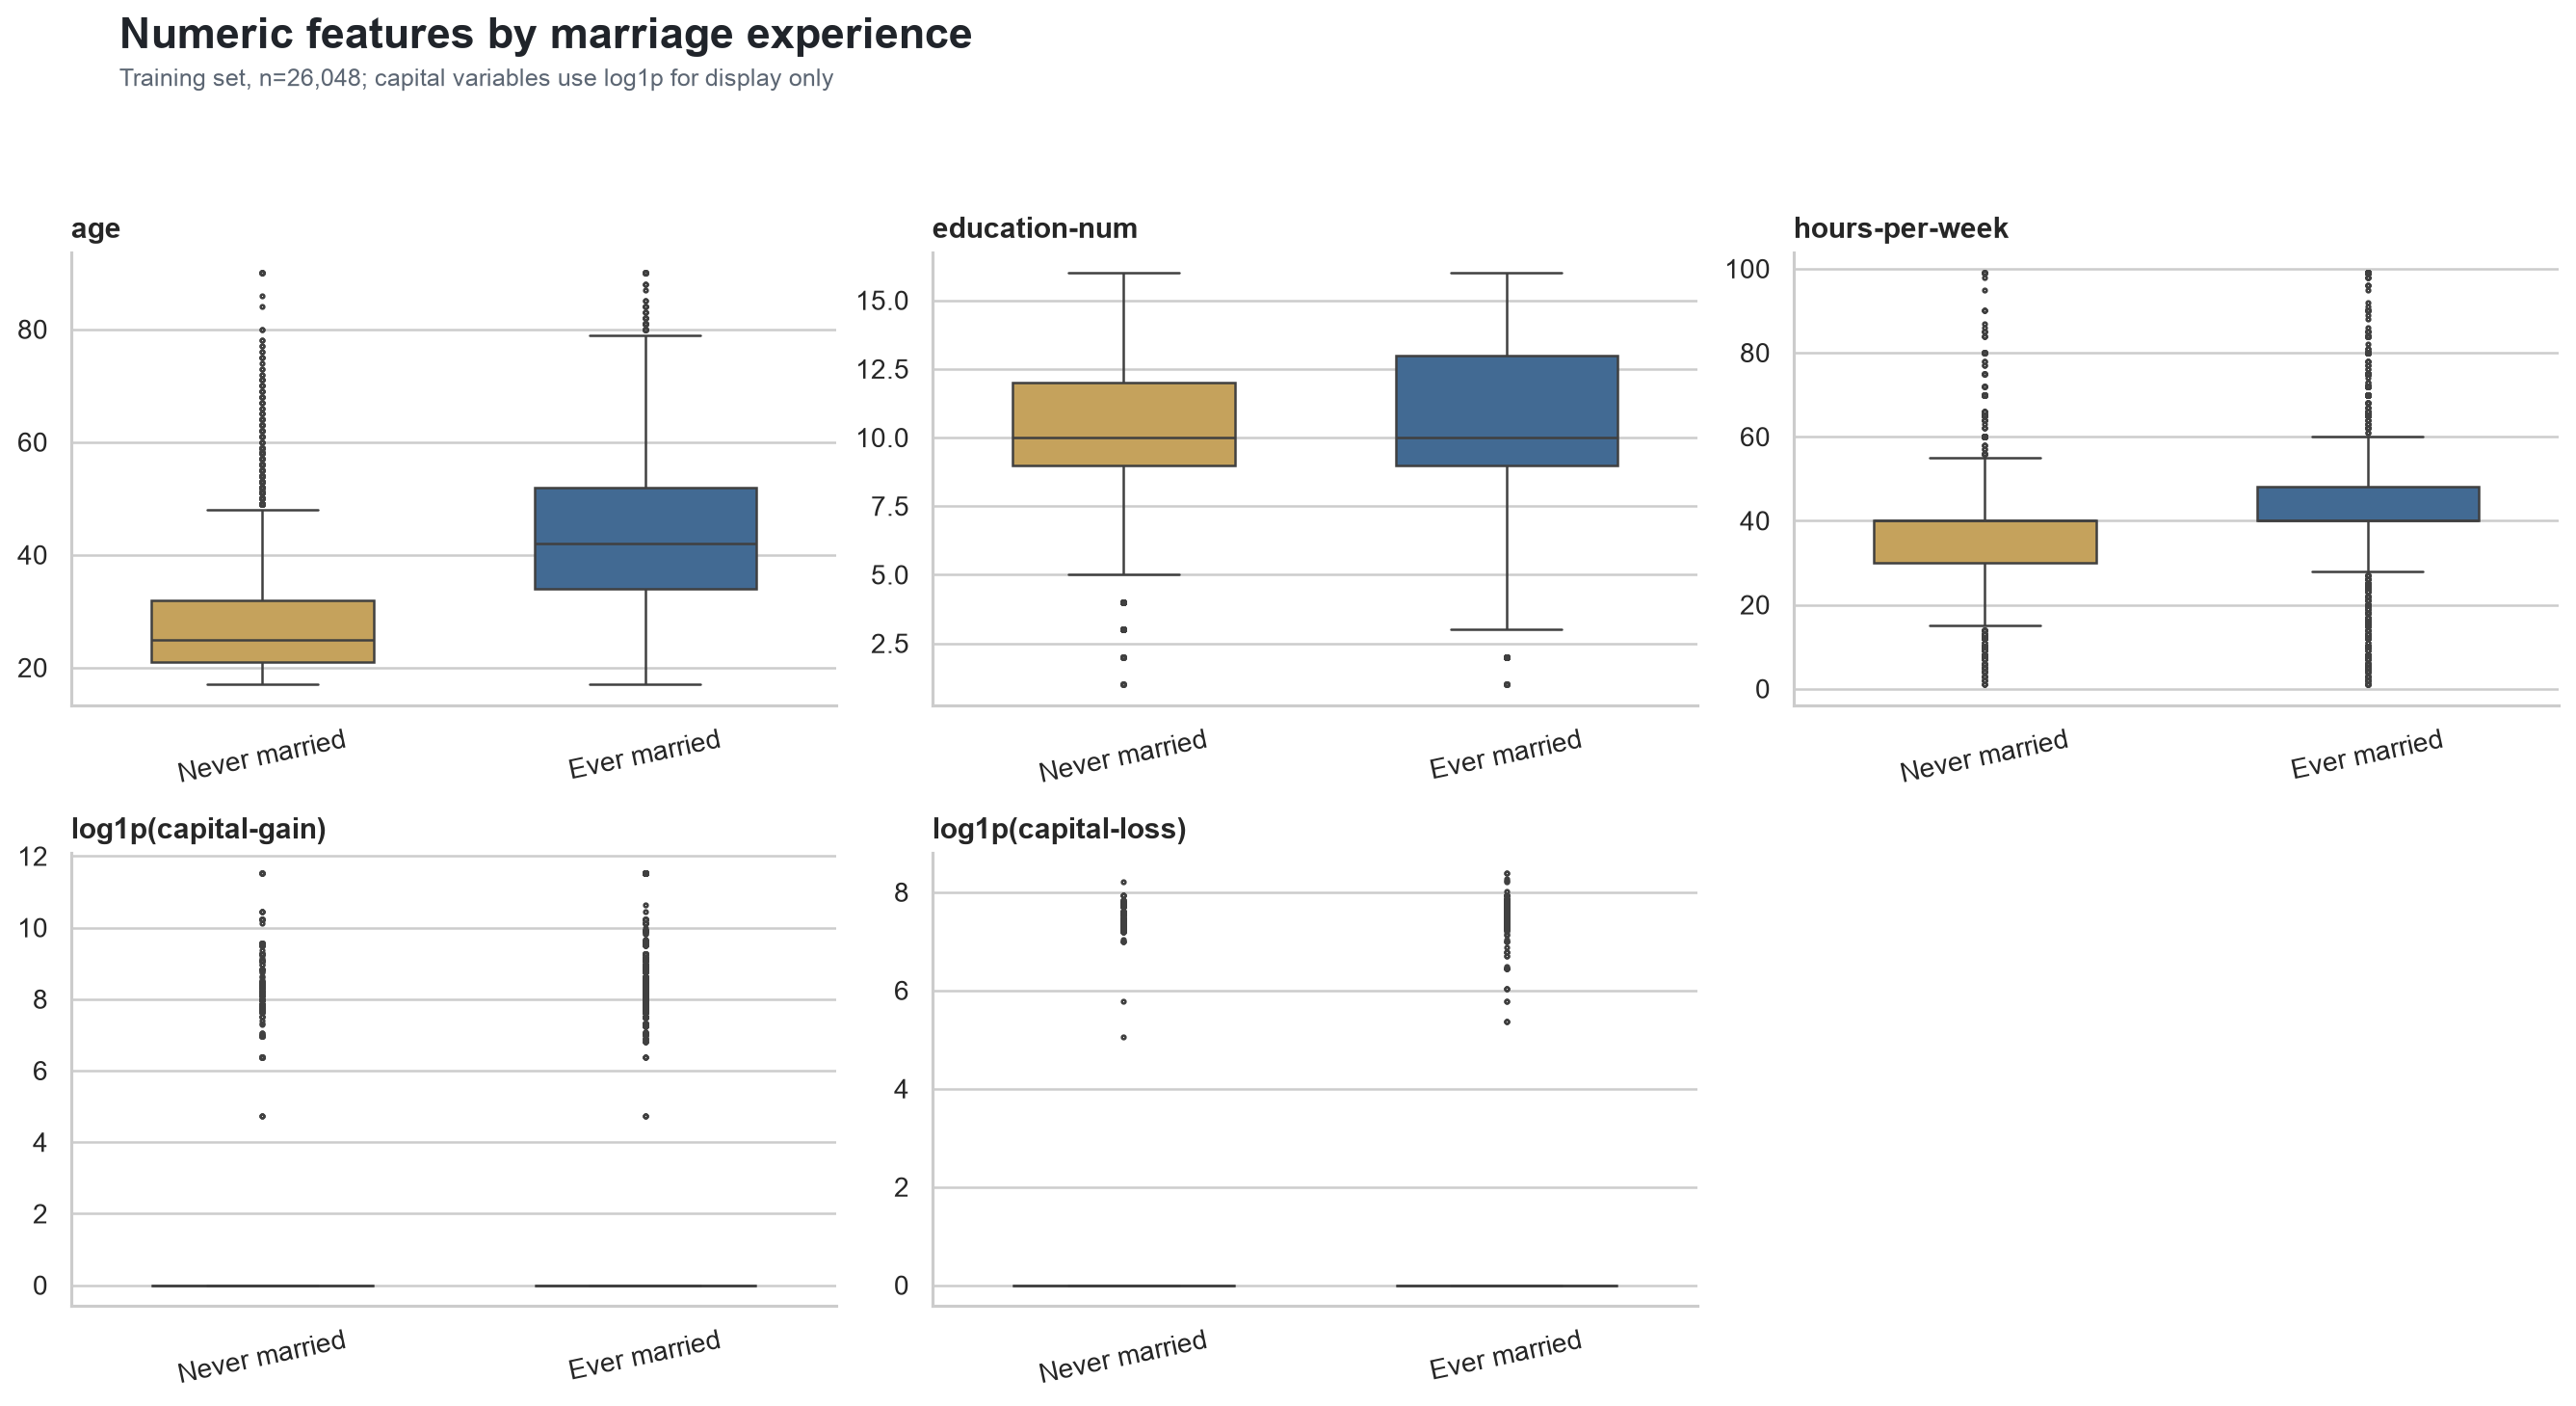

In [14]:
numeric_target_chart_path = create_numeric_target_boxplots(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_numeric_by_target.png',
)
display(Image(filename=str(numeric_target_chart_path)))

### 8. Point-biserial 상관계수와 Welch t-test

In [15]:
numeric_associations = analyze_numeric_associations(train_df)
numeric_associations.round(4)

,feature,point_biserial_r,correlation_p_value,mean_ever_married_1,mean_ever_married_0,mean_difference,welch_t_statistic,welch_p_value,cohens_d,welch_p_holm
0,age,0.5340,0.0,43.6730,28.1837,15.4892,108.8689,0.0,1.3452,0.0
1,hours-per-week,0.1988,0.0,42.1487,36.9193,5.2294,32.3347,0.0,0.4321,0.0
2,capital-gain,0.0655,0.0,1449.4873,396.4385,1053.0488,13.2889,0.0,0.1397,0.0
3,capital-loss,0.0616,0.0,104.9631,51.9714,52.9916,11.2643,0.0,0.1315,0.0
4,education-num,0.0299,0.0,10.1414,9.9775,0.1638,5.0158,0.0,0.0638,0.0


p-value가 매우 작더라도 효과크기가 작을 수 있습니다. 예를 들어 `education-num`은 통계적으로 유의하지만 Cohen's d가 약 0.064로 작습니다.

### 9. 범주형 chi-square와 Cramér's V

In [16]:
categorical_associations = analyze_categorical_associations(train_df)
categorical_associations.round(4)

,feature,categories,chi2,degrees_of_freedom,p_value,cramers_v,p_holm
0,income,2,2613.2964,1,0.0,0.3167,0.0
1,occupation,15,1329.4540,14,0.0,0.2247,0.0
2,workclass,9,627.6183,8,0.0,0.1542,0.0


### 10. 범주에 따라 Target=1 비율이 달라지는가?

각 범주의 표본 수와 혼인 경험 비율을 확인합니다. 표본 수가 작은 범주의 극단적인 비율은 주의해서 해석합니다.

In [17]:
categorical_target_rates = build_categorical_target_rates(train_df)
print('[Question] 범주에 따라 Target=1 비율이 달라지는가?')
display(categorical_target_rates.round(2))
print('[Next Action] 범주를 임의 통합하지 않고 Unknown 대치 + OneHotEncoder를 적용하며, 예측 기여는 교차검증으로 판단합니다.')

[Question] 범주에 따라 Target=1 비율이 달라지는가?


,feature,category,sample_size,ever_married_count,target_rate_pct
0,workclass,Federal-gov,763,566,74.18
1,workclass,Local-gov,1662,1235,74.31
2,workclass,Missing,1506,872,57.90
3,workclass,Never-worked,6,2,33.33
4,workclass,Private,18168,11649,64.12
5,workclass,Self-emp-inc,901,797,88.46
6,workclass,Self-emp-not-inc,1980,1659,83.79
7,workclass,State-gov,1048,712,67.94
8,workclass,Without-pay,14,10,71.43
9,occupation,Adm-clerical,2986,1730,57.94


[Next Action] 범주를 임의 통합하지 않고 Unknown 대치 + OneHotEncoder를 적용하며, 예측 기여는 교차검증으로 판단합니다.


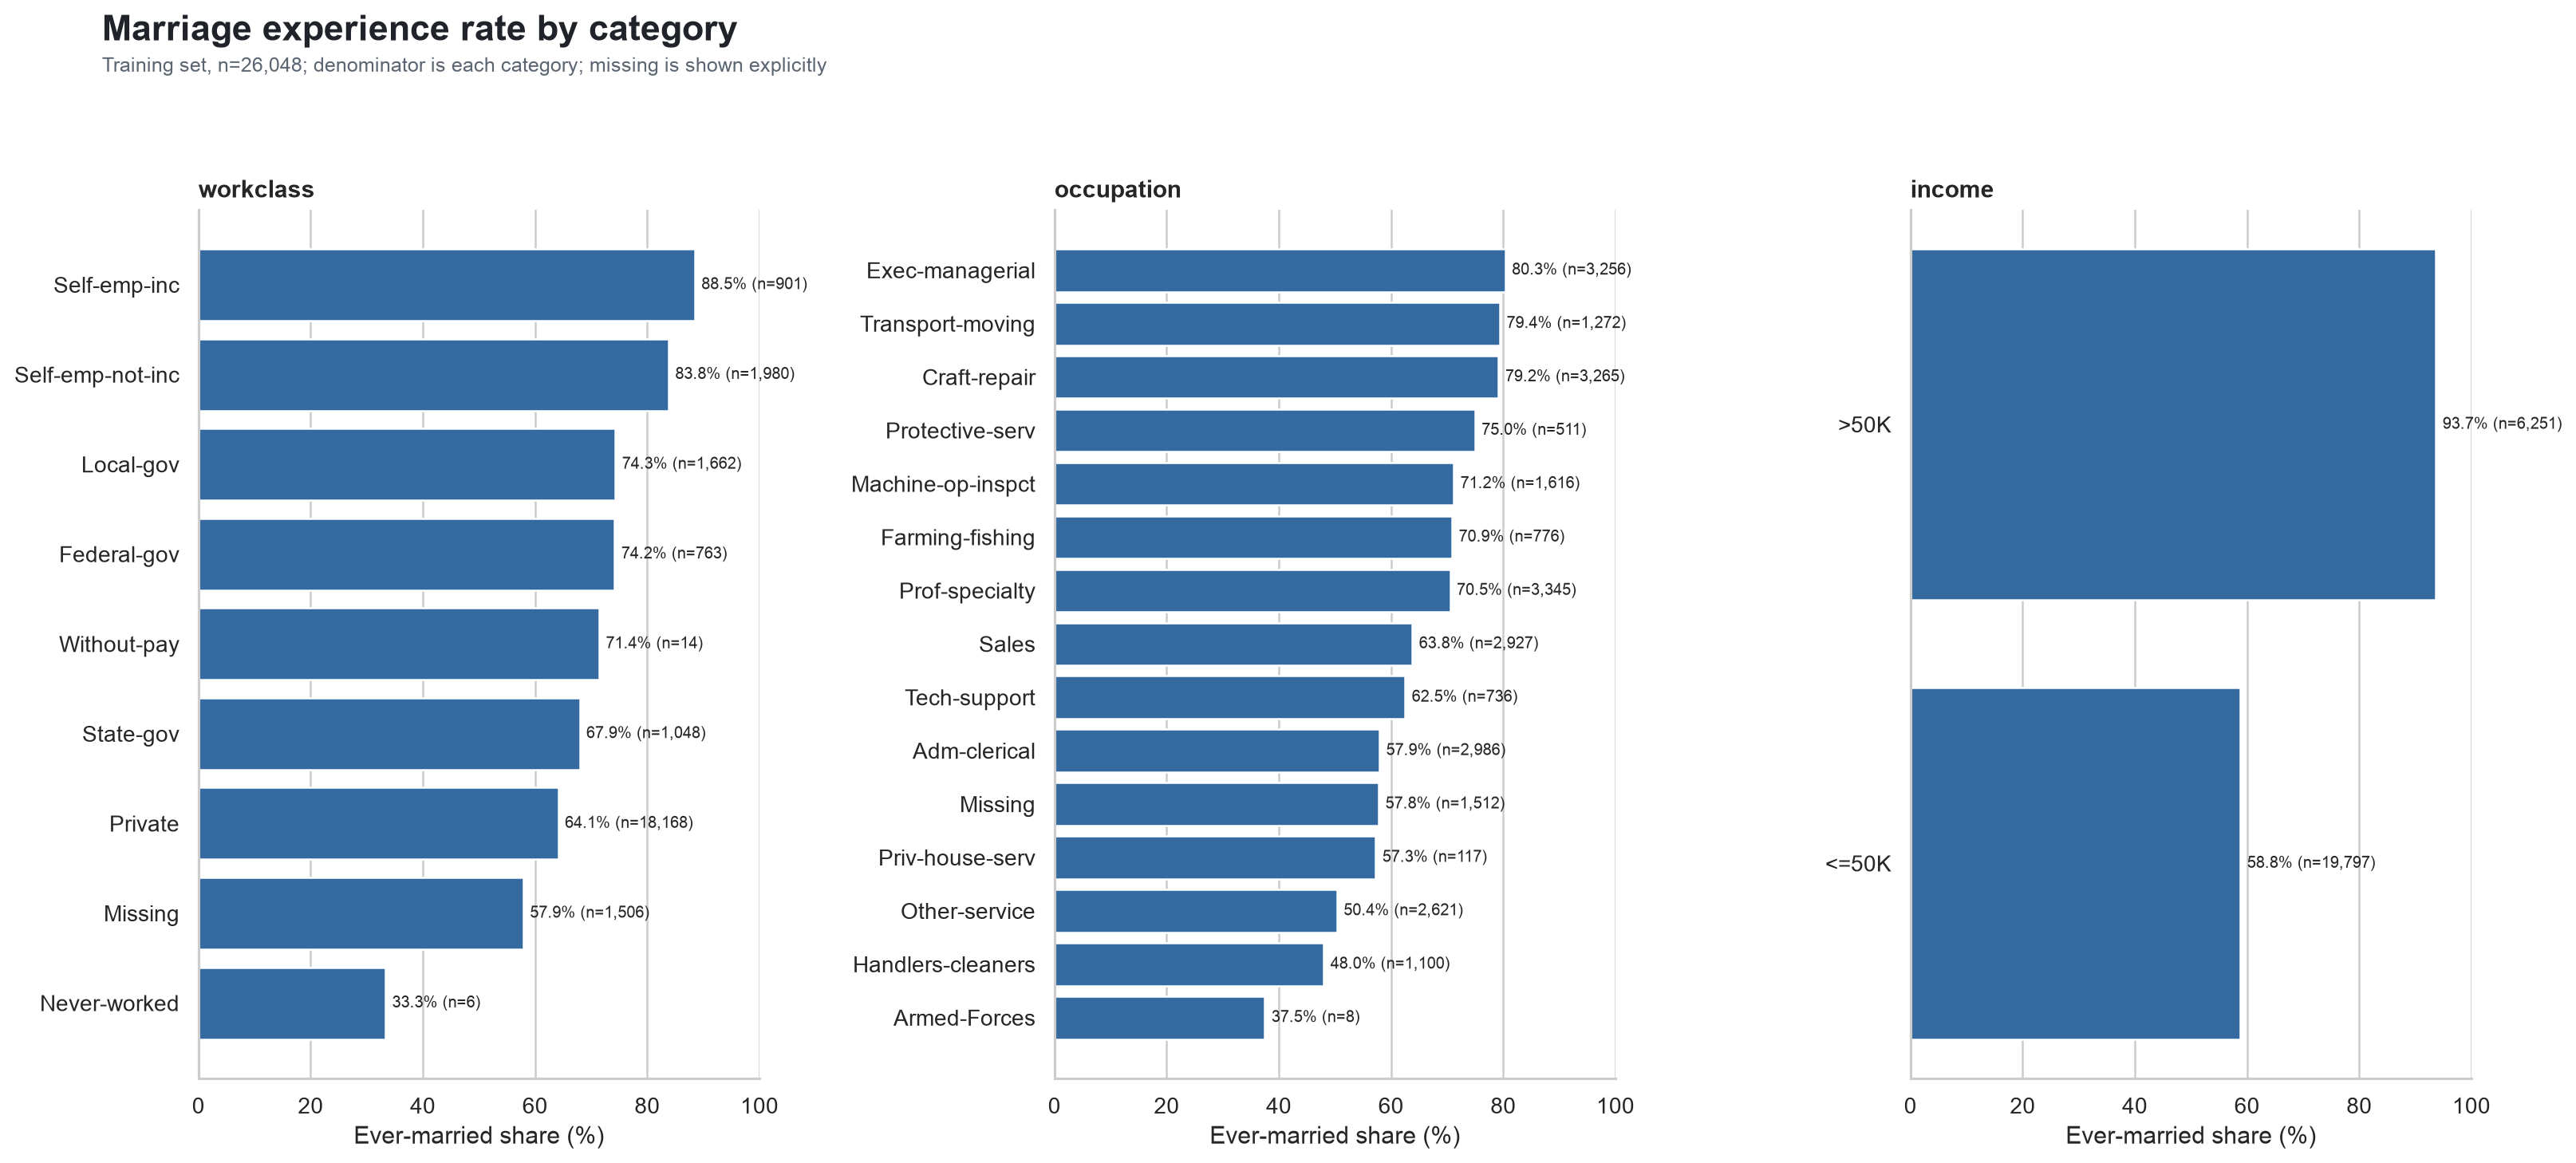

In [18]:
categorical_target_chart_path = create_categorical_target_rate_chart(
    train_df,
    project_root / 'reports' / 'figures' / 'eda_categorical_target_rates.png',
)
display(Image(filename=str(categorical_target_chart_path)))

### 11. Mutual Information 순위

In [19]:
mutual_information = calculate_mutual_information(train_df)
mutual_information.round(4)

,feature,mutual_information
0,age,0.2120
1,income,0.0613
2,hours-per-week,0.0290
3,occupation,0.0257
4,capital-gain,0.0211
5,workclass,0.0133
6,capital-loss,0.0132
7,education-num,0.0123


### 11-1. 상관계수·Cramér’s V·Mutual Information 시각화

서로 단위가 다른 세 지표를 각각의 패널에서 순위로 확인합니다. 지표 간 막대 길이를 직접 비교하지 않습니다.

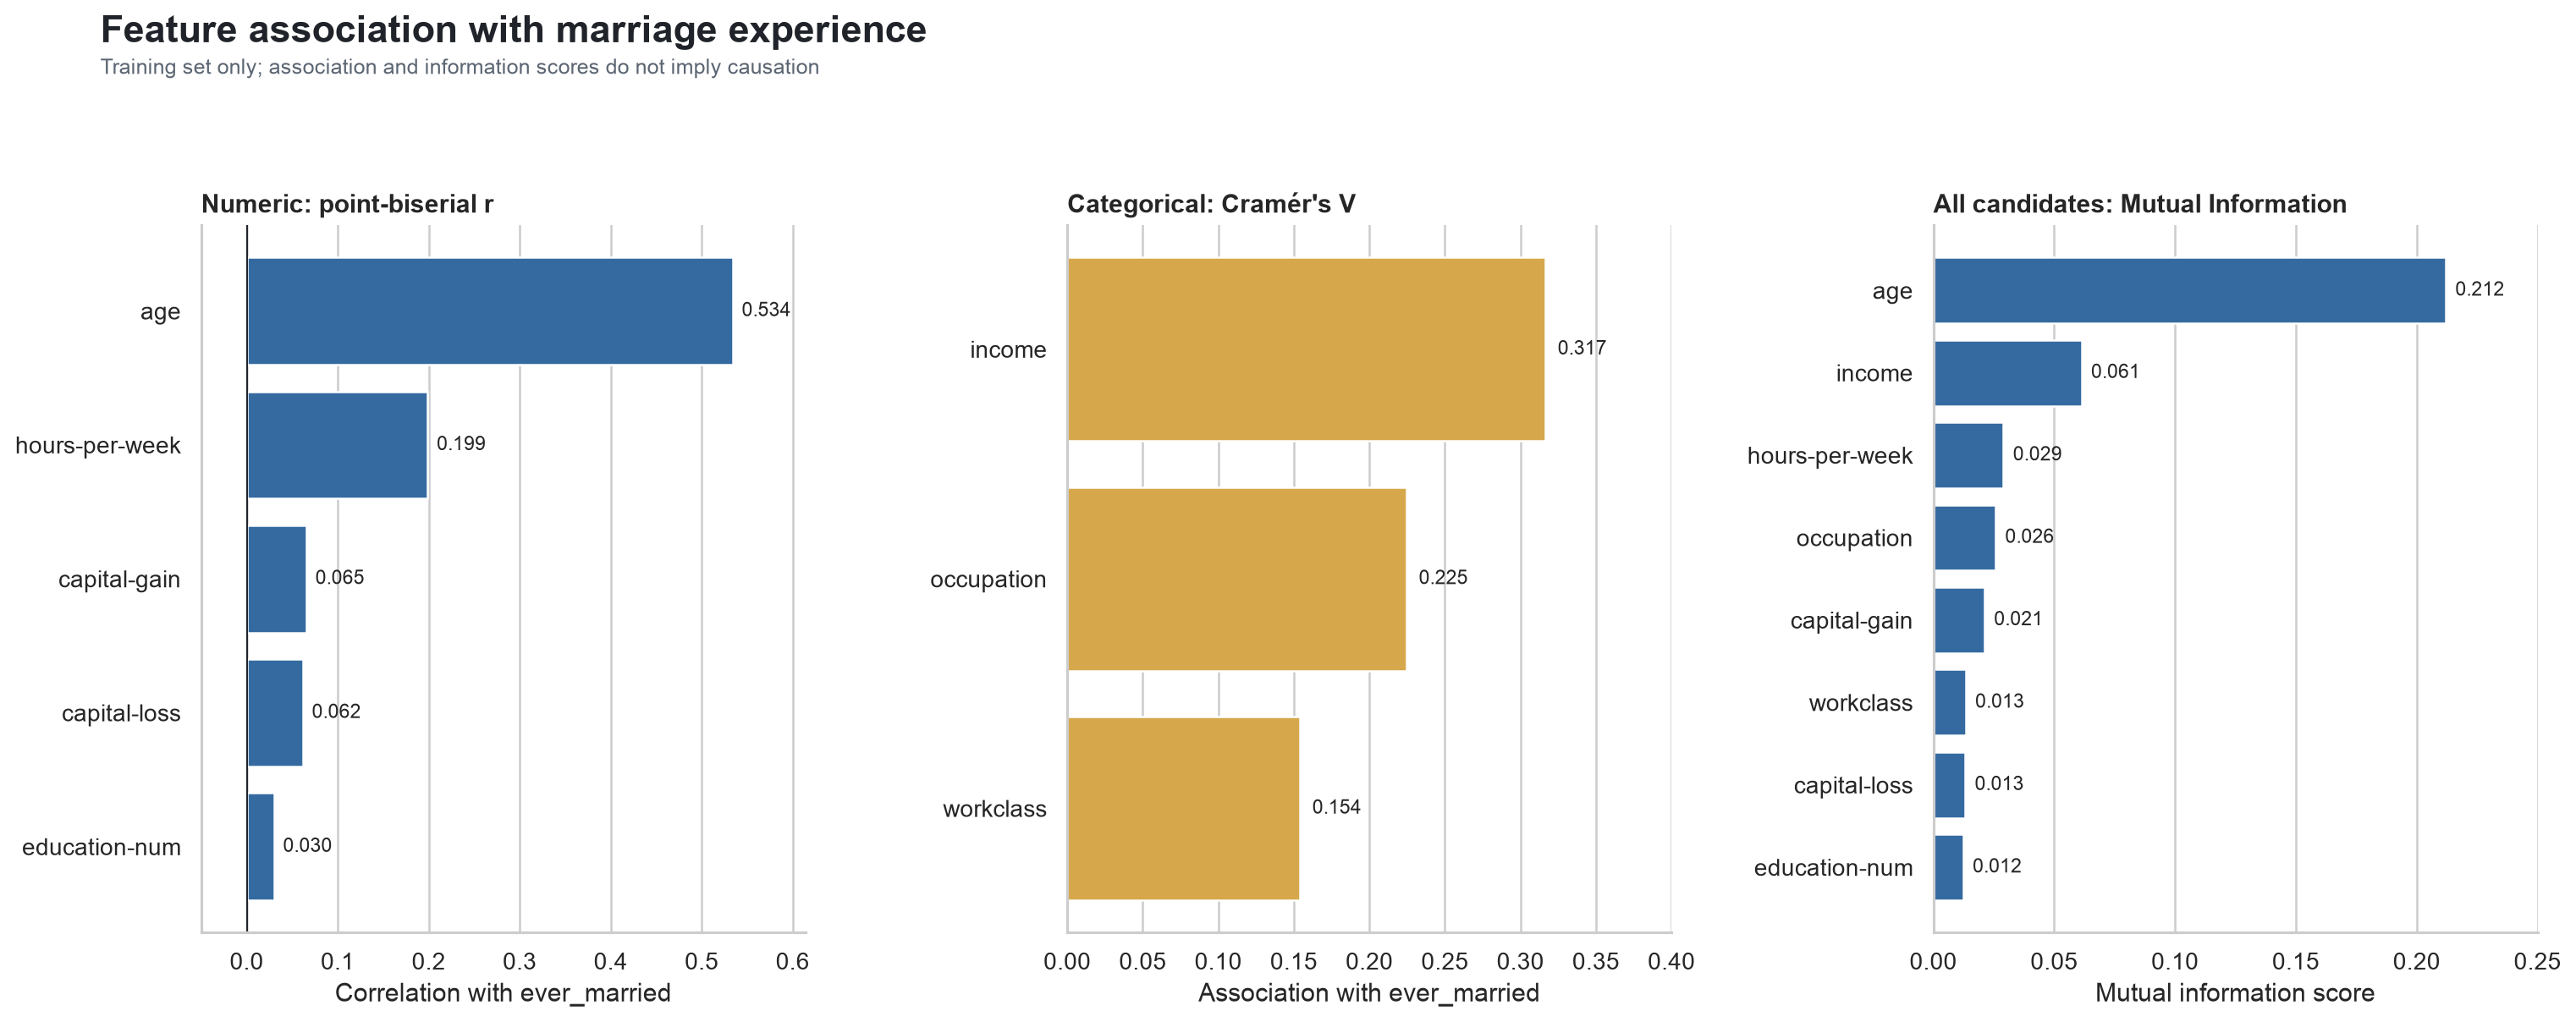

In [20]:
association_chart_path = create_target_association_overview(
    numeric_associations,
    categorical_associations,
    mutual_information,
    project_root / 'reports' / 'figures' / 'eda_target_associations.png',
)
display(Image(filename=str(association_chart_path)))

### 12. Seaborn 정적 차트 — 집단별 나이 분포

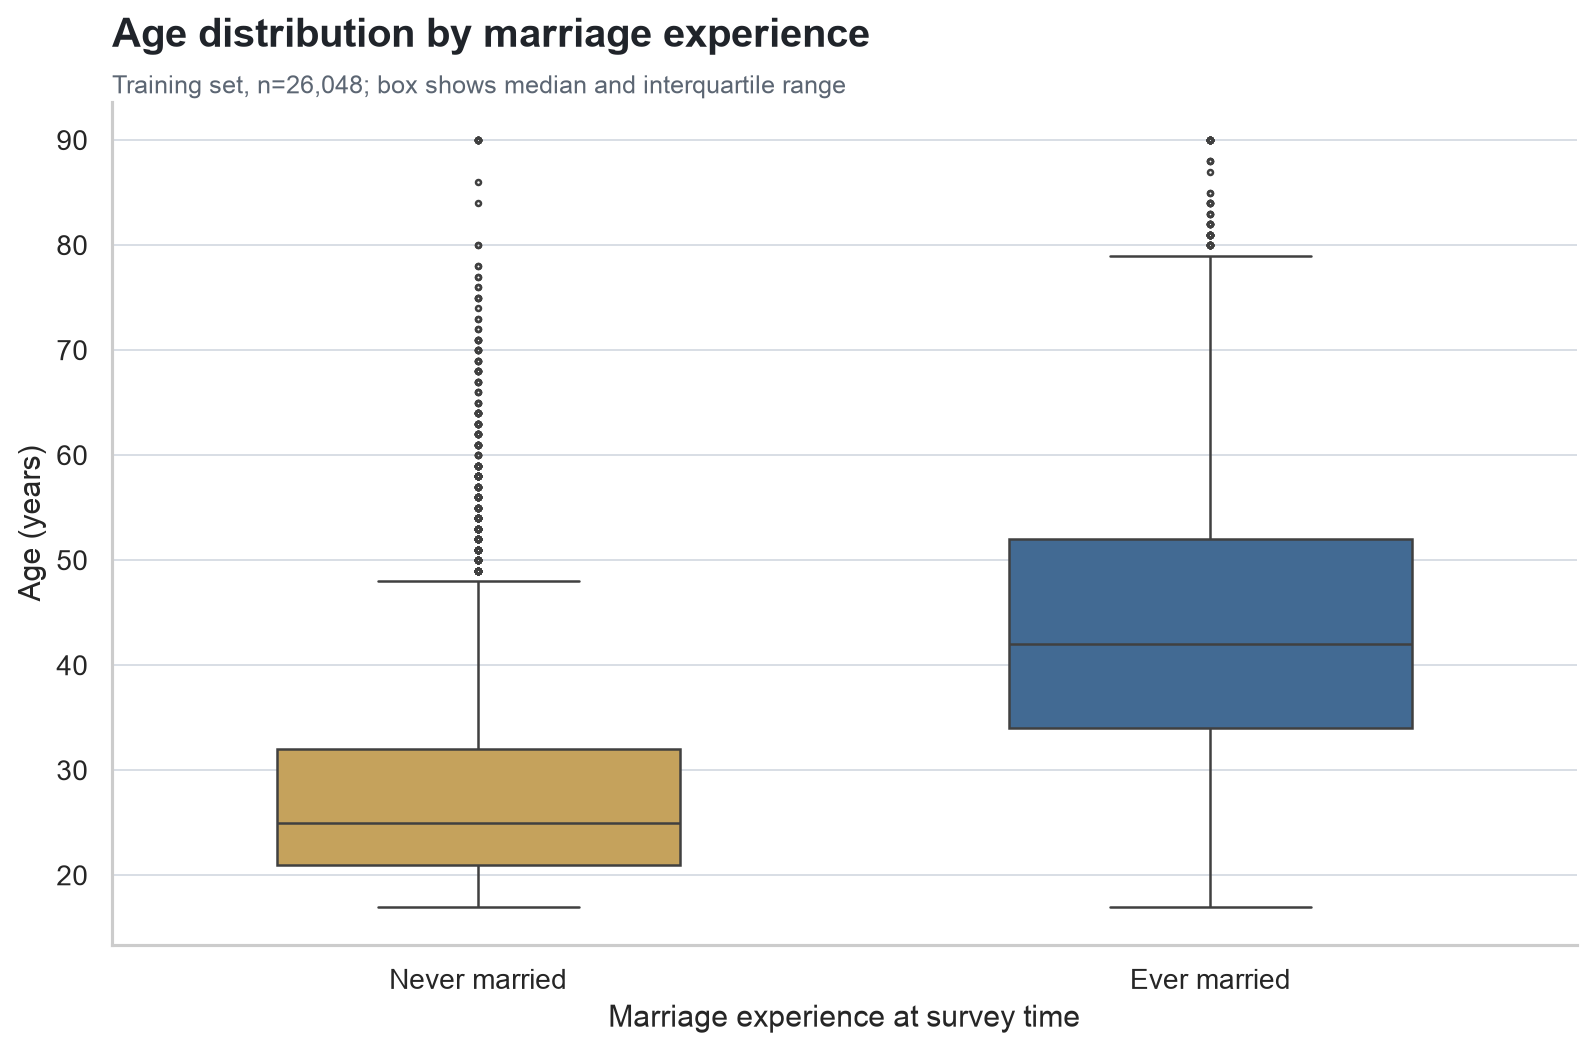

In [21]:
static_chart_path = create_age_distribution_chart(
    train_df,
    project_root / 'reports' / 'figures' / 'age_distribution_by_marriage.png',
)
display(Image(filename=str(static_chart_path)))

### 13. Plotly 인터랙티브 차트 — 연령대별 혼인 경험 비율

In [22]:
interactive_chart_path = create_interactive_age_rate_chart(
    train_df,
    project_root / 'reports' / 'interactive' / 'marriage_rate_by_age_group.html',
)
age_rate_figure = build_age_rate_figure(train_df)
age_rate_figure.show()

## Checks

분할과 분석 범위를 자동 검증합니다.

In [23]:
assert len(train_df) == 26_048
assert len(test_df) == 6_513
assert set(train_df.index).isdisjoint(test_df.index)
assert split_summary.groupby('split')['percentage'].sum().round(8).eq(100).all()
assert numeric_associations.iloc[0]['feature'] == 'age'
assert mutual_information.iloc[0]['feature'] == 'age'
assert split_target_chart_path.exists() and split_target_chart_path.stat().st_size > 0
assert association_chart_path.exists() and association_chart_path.stat().st_size > 0
assert distribution_chart_path.exists() and distribution_chart_path.stat().st_size > 0
assert outlier_chart_path.exists() and outlier_chart_path.stat().st_size > 0
assert categorical_chart_path.exists() and categorical_chart_path.stat().st_size > 0
assert correlation_chart_path.exists() and correlation_chart_path.stat().st_size > 0
assert numeric_target_chart_path.exists() and numeric_target_chart_path.stat().st_size > 0
assert categorical_target_chart_path.exists() and categorical_target_chart_path.stat().st_size > 0
assert static_chart_path.exists() and static_chart_path.stat().st_size > 0
assert interactive_chart_path.exists() and interactive_chart_path.stat().st_size > 0

print('검증 완료: 분할·통계분석·필수 시각화가 정상입니다.')

검증 완료: 분할·통계분석·필수 시각화가 정상입니다.


## Takeaways

1. 나이는 현재까지의 혼인 경험을 구분하는 가장 강한 단일 후보입니다. 다만 이를 최적 단일 모델로 확정하려면 다음 단계의 교차검증이 필요합니다.
2. 17–24세의 혼인 경험 비율은 약 12.6%, 45–54세는 약 91.3%로 연령 노출 효과가 매우 큽니다.
3. `education-num`은 p-value만 보면 유의하지만 실제 집단 차이는 작아 p-value와 효과크기를 함께 해석해야 합니다.
4. 다음 단계에서는 전처리 Pipeline을 만들고 각 단일 특성 모델을 동일한 교차검증으로 평가합니다.